In [ ]:
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
from scipy.stats import chi2

## Examples

#### Reweight `stop_M1000_975_ct0p2_2018` to its true $c\tau$

In [241]:
sample = {
    "model": "stop",
    "mLLP" : 1000,
    "dm"   : 25,
    "orig_ctau" : 0.2,
    "orig_BR" : 0.5
}

if sample["model"] == "stop":
    ctau_new = getctauBR(1000, 25, sample['orig_BR'])
    print('new ctau: ', ctau_new)

    w_ct0 = getctauweight(d[plane]['LLP_ctau0'], sample["orig_ctau"], ctau_new)
    w_ct1 = getctauweight(d[plane]['LLP_ctau1'], sample["orig_ctau"], ctau_new)
    w  = w_ct0 * w_ct1 
    print([round(i,2) for i in w[:10]])
w.mean()

new ctau:  0.2125595964881454
[1.28, 0.97, 1.13, 1.09, 1.01, 0.9, 0.98, 1.05, 0.95, 1.33]


1.0629658

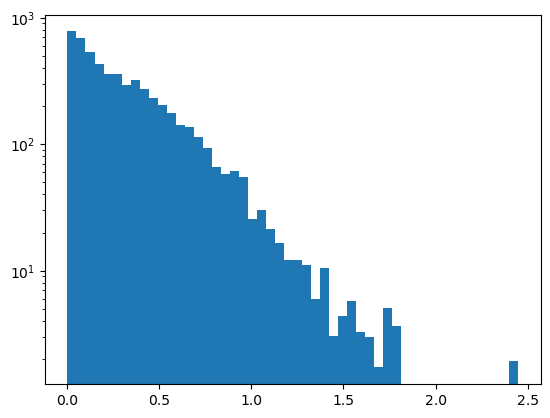

In [240]:
import matplotlib.pyplot as plt
plt.hist(d[plane]['LLP_ctau0']*10, weights=w, bins=50)
plt.yscale('log')
plt.show()

In [243]:
w

array([1.2755008 , 0.97269696, 1.1290226 , ..., 1.0210878 , 1.087945  ,
       0.97806126], dtype=float32)

#### Reweight `stop_M1000_975_ct0p2_2018` to a different BR scenario

In [2]:
sample = {
    "model": "stop",
    "mLLP" : 1000,
    "dm"   : 25,
    "orig_ctau" : 0.2,
    "orig_BR" : 0.5
}


plane = 'GT3'

if sample["model"] == "stop":
    target_BR = 0.5
    ctau_new = getctauBR(1000, 25, target_BR)
    print('target_BR: ', target_BR)
    print('ctau new: ', ctau_new)

    w_ct0 = getctauweight(d[plane]['LLP_ctau0'], sample["orig_ctau"], ctau_new)
    w_ct1 = getctauweight(d[plane]['LLP_ctau1'], sample["orig_ctau"], ctau_new)
    w_BR1 = getBRweight(d[plane]['LLP_decaymode0'], origin=sample['orig_BR'], target=target_BR)
    w_BR2 = getBRweight(d[plane]['LLP_decaymode1'], origin=sample['orig_BR'], target=target_BR)
    w  = w_ct0 * w_ct1 * w_BR1 * w_BR2
    max_allowed_w = 100
    w = np.where(w > max_allowed_w, 0, w)


print('mean weight: ', w.mean())
print('min weight: ',  w.min())
print('max weight: ',  w.max())

NameError: name 'getctauBR' is not defined

## OOP

In [3]:
%cd CMSSW_15_0_5/src/SoftDisplacedVertices/Plotter/limitcalc/limitcalc_oop/

/users/alikaan.gueven/AOD_to_nanoAOD/Plotter_run3/CMSSW_15_0_5/src/SoftDisplacedVertices/Plotter/limitcalc/limitcalc_oop


In [ ]:
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt
from scipy.stats import chi2

from pathlib import Path
import numpy as np
import utils
import pickle as pkl


class SignalReweighter:
    def __init__(self, file_path):
        self.file_path = Path(file_path)
        self.d = self.read_pickle()
 
        self.name = self.file_path.stem
        sample_info = utils.parse_signal_name(self.name)

        self.model = sample_info.model
        self.M     = sample_info.M
        self.dM    = sample_info.dM
        self.ct    = sample_info.ct

        self.full_evt_weight = None




    def read_pickle(self):
        with open(self.file_path, 'rb') as f:
            d = pkl.load(f)
        return d
    

    def calc_ctauBR_weights(self, plane, target_BR=None, target_ctau=None):
        """
        Calculate ctau and BR weights for stops.
            return single number per event
        
        Calculate ctau weights for C1N2.
            return single number per event
        """
        if self.model == "stop":
            if target_BR is None:
                target_BR = 0.5

            if target_ctau is None:
                target_ctau = utils.get_stop_ctau_for_br(self.M, self.dM, target_BR)

            w_ct0 = utils.get_ctau_weight(self.d[plane]["LLP_ctau0"], self.ct, target_ctau)
            w_ct1 = utils.get_ctau_weight(self.d[plane]["LLP_ctau1"], self.ct, target_ctau)

            w_BR0 = utils.get_stop_decay_mode_br_weight(
                self.d[plane]["LLP_decaymode0"], origin=0.5, target=target_BR
            )
            w_BR1 = utils.get_stop_decay_mode_br_weight(
                self.d[plane]["LLP_decaymode1"], origin=0.5, target=target_BR
            )

            w = w_ct0 * w_ct1 * w_BR0 * w_BR1
            return w

        elif self.model == "C1N2":
            if target_ctau is None:
                raise ValueError("target_ctau must be provided for C1N2.")

            w = utils.get_ctau_weight(self.d[plane]["LLP_ctau0"], self.ct, target_ctau)
            return w
        
        else:
            raise ValueError(f"Unsupported model: {self.model}")
        
    def get_fullevt_weight(self, target_BR=None, target_ctau=None):
        self.full_evt_weight = {}

        for plane in self.d.keys():
            ctauBR_weight = self.calc_ctauBR_weights(self, plane, target_BR=target_BR, target_ctau=target_ctau)
            evt_weight = self.d[plane]['evt_weight']
            self.full_evt_weight[plane] = ctauBR_weight * evt_weight

        
    def getSum(self, MET, ML, MET_lo, ML_lo):
        """
        Regions
        -------
        ML
        ^
        |  B  |  A
        | --- | ---
        |  D  |  C
        |-----------> MET


        Parameters
        ----------
        MET: MET boundary between regions A & B
        ML:  MLscore boundary between regions A & C.
        MET_lo: Lower MLscore boundary for the regions B & D.
        ML_lo:  Lower MLscore boundary for the regions C & D.
        """
        out = {}

        if self.full_evt_weight is None:
            raise ValueError('Event weight is not constructed.\nCall get_fullevt_weight first.')


        for plane in self.d.keys():
            evt_weight  = self.d[plane]['evt_weight']
            LLP_MET_pt  = self.d[plane]['LLP_MET_pt']
            LLP_MLscore = self.d[plane]['LLP_MLscore']


            is_A = ((LLP_MET_pt  >= MET) &
                    (LLP_MLscore >= ML))
            
            is_B = ((LLP_MET_pt  <  MET)    &
                    (LLP_MET_pt  >= MET_lo) &
                    (LLP_MLscore >= ML))
            
            is_C = ((LLP_MET_pt  >= MET)   &
                    (LLP_MLscore <  ML)    &
                    (LLP_MLscore >= ML_lo))
            
            is_D = ((LLP_MET_pt >=  MET_lo)    &
                    (LLP_MET_pt <   MET)       &
                    (LLP_MLscore <  ML)        &
                    (LLP_MLscore >= ML_lo))
            
            out[plane] = {
            "A": np.sum(evt_weight[is_A]),
            "B": np.sum(evt_weight[is_B]),
            "C": np.sum(evt_weight[is_C]),
            "D": np.sum(evt_weight[is_D])
        }

        return out

filepath = "my_mockup_file.pkl"
mysample = SignalReweighter(filepath)
mysample.get_fullevt_weight(target_BR=None, target_ctau=None)
counts = mysample.getSum(500, 0.999, 250, 0.80)


# From now on I can give the counts to the datacard tool
# as counts['GT0']['A'], counts['GT0']['B'], ...

In [105]:
filepath = "/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/AN-25-092_ML_plots_limitcalc_merge_w_Ang_v3_centralprod/sig_2018/stop_M1000_975_ct0p2_2018_hist0.pkl"
mysample = SignalReweighter(filepath)

In [106]:
np.argmax(mysample.calc_ctauBR_weights(plane='GT0', target_BR=None, target_ctau=None))

32515

In [107]:
mysample.d['GT0']['LLP_ctau0'][59763]

23.53125

In [108]:
mysample.d['GT0']['LLP_ctau1'][59763]

0.023986816

In [109]:
mysample

In [110]:
filepath = "/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/AN-25-092_ML_plots_limitcalc_merge_w_Ang_v3_centralprod/sig_2018/stop_M1000_975_ct0p2_2018_hist0.pkl"
mysample = SignalReweighter(filepath)

In [ ]:
target_BR = 1.0
print('True target ctau:', utils.get_stop_ctau_for_br(mysample.M, mysample.dM, target_BR))

True target ctau: 0.4251191929762908


In [115]:
plane = 'GT0'

w = mysample.calc_ctauBR_weights(plane, target_BR)

min_w  = np.min(w)
max_w  = np.max(w)
mean_w = np.mean(w)

print('min_w: ', min_w)
print('max_w: ', max_w)
print('mean_w: ', mean_w)

min_w:  0.0
max_w:  4302.3642578125
mean_w:  1.2231878437142722


True target ctau: 0.4251191929762908
GT0 LLP_ctau0: weighted mean = 2.0487 mm
GT0 LLP_ctau1: weighted mean = 1.5345 mm
GT1 LLP_ctau0: weighted mean = 1.1633 mm
GT1 LLP_ctau1: weighted mean = 2.0560 mm
GT2 LLP_ctau0: weighted mean = 0.5783 mm
GT2 LLP_ctau1: weighted mean = 0.6044 mm
GT3 LLP_ctau0: weighted mean = 0.6507 mm
GT3 LLP_ctau1: weighted mean = 0.6440 mm


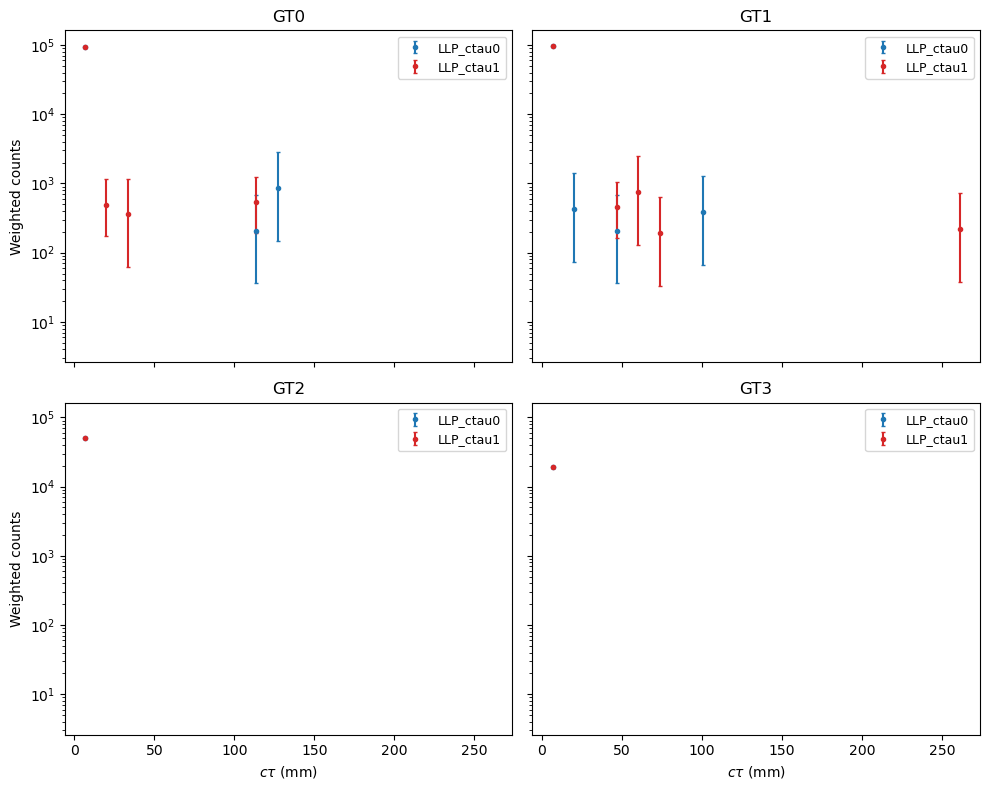

In [118]:
print('True target ctau:', utils.get_stop_ctau_for_br(mysample.M, mysample.dM, target_BR))
_ = mysample.plot_LLPs_all_planes(target_BR=target_BR)

In [23]:
planes=("GT0", "GT1", "GT2", "GT3")
for plane in planes:
    print(sum(mysample.calc_ctauBR_weights(plane=plane, target_BR=None, target_ctau=None)))

77482.76277273893
67094.84453743696
26381.042350828648
5540.999445617199


In [ ]:
def plot_LLPs(d, plane, w):
    mask = (w != 0)
    ww = w[mask]

    x = {
        "LLP_ctau0": d[plane]["LLP_ctau0"][mask] * 10,
        "LLP_ctau1": d[plane]["LLP_ctau1"][mask] * 10,
    }

    for label in x.keys():
        x_mean = np.average(x[label], weights=ww)
        print('label: ', label)
        print('new mean: ', x_mean)
        print()

    bins = np.histogram_bin_edges(np.concatenate(list(x.values())), bins=20)
    centres = 0.5 * (bins[1:] + bins[:-1])

    for label, color in [("LLP_ctau0", "tab:blue"),
                         ("LLP_ctau1", "tab:red")]:
        y, yerr = poisson_yerr(x[label], ww, bins)

        plt.errorbar(
            centres,
            y,
            yerr=yerr,
            fmt="o",
            color=color,
            label=label,
            markersize=3,
            capsize=1.5
        )

    plt.xlabel(r'$c\tau$ (mm)')
    plt.ylabel(r'Weighted counts')
    plt.yscale("log")
    plt.legend()
    plt.show()

plot_LLPs(d, plane, w)

#### Reweight `C1N2_M200_175_ct0p2_2018` to a different $c\tau$ scenario

In [214]:
filepath = "/scratch-cbe/users/alikaan.gueven/AN_plots/ParT_hists/AN-25-092_ML_plots_limitcalc_merge_w_Ang_v3_centralprod/sig_2018/C1N2_M200_175_ct200_2018_hist0.pkl"

with open(filepath, 'rb') as f:
    d = pkl.load(f)

In [234]:
sample = {
    "model": "C1N2",
    "mLLP" : 500,
    "dm"   : 25,
    "orig_ctau" : 200
}

if sample["model"] == "C1N2":
    new_ctau = 200
    w = getctauweight(d[plane]['LLP_ctau0'], sample["orig_ctau"], new_ctau)
    print([round(i,2) for i in w[:10]])
print('mean: ', w.mean())
print('min: ', w.min())
print('max: ', w.max())

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
mean:  1.0
min:  1.0
max:  1.0


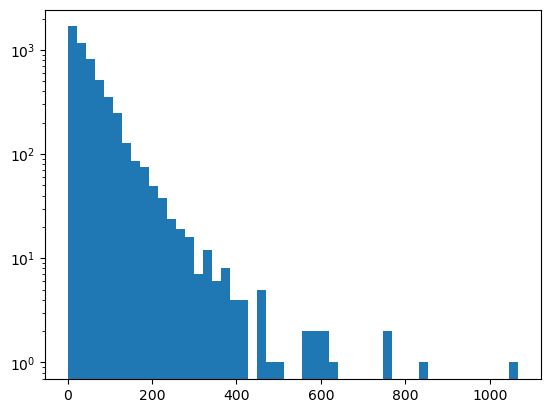

In [235]:
import matplotlib.pyplot as plt
plt.hist(d[plane]['LLP_ctau0']*10, weights=w, bins=50)
plt.yscale('log')
plt.show()

In [212]:
d[plane]['LLP_ctau0']

array([0.06848145, 0.01605225, 0.05258179, ..., 0.03652954, 0.06671143,
       0.01991272], dtype=float32)